In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Import zipfile for extraction
import zipfile

# Set the path to your new zip file in Google Drive
zip_path = "/content/drive/MyDrive/UTSW-Glioma.zip"

# Set extraction folder
extract_path = "/content/UTSW-Glioma"

# Extract the zip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("UTSWGlioma extracted successfully")

UTSWGlioma extracted successfully


In [37]:
import os
base_path = os.path.join(extract_path, "UTSW-Glioma")  # adjust if needed

patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT1143', 'BT0144', 'BT1019', 'BT0252', 'BT0965']


Showing images for: BT1143
Shape: (240, 240, 155)


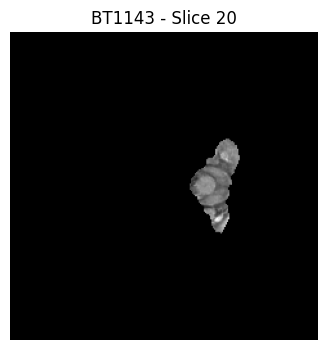

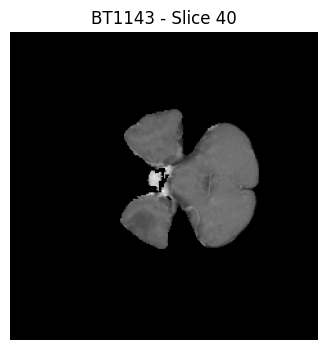

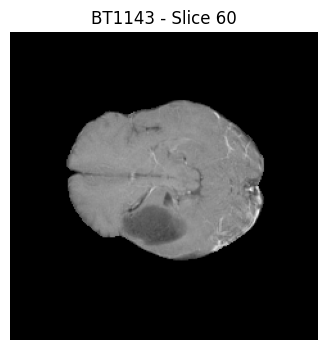

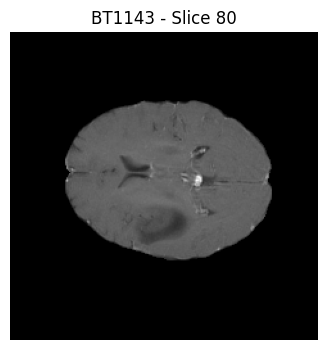

In [38]:
import nibabel as nib
import matplotlib.pyplot as plt

# Pick first patient
sample_patient = patients[0]
patient_path = os.path.join(base_path, sample_patient)

print("Showing images for:", sample_patient)

# Choose one modality (you can change this)
mri_path = os.path.join(patient_path, "brain_t1ce.nii.gz")

# Load MRI
img = nib.load(mri_path)
data = img.get_fdata()

print("Shape:", data.shape)

# Show multiple slices
slice_indices = [20, 40, 60, 80]

for i in slice_indices:
    if i < data.shape[2]:
        plt.figure(figsize=(4,4))
        plt.imshow(data[:, :, i], cmap="gray")
        plt.title(f"{sample_patient} - Slice {i}")
        plt.axis("off")
        plt.show()

In [39]:
import os

extract_path = "/content/UTSW-Glioma"

print("Level 1:", os.listdir(extract_path))

Level 1: ['UTSW-Glioma']


In [41]:
inner = os.listdir(extract_path)[0]
print("Level 2:", os.listdir(os.path.join(extract_path, inner)))

Level 2: ['BT1143', 'BT0144', 'BT1019', 'BT0252', 'BT0965', 'BT0078', 'BT1011', 'BT0091', 'BT0907', 'BT0782', 'BT1229', 'BT0127', 'BT1311', 'BT0828', 'BT0436', 'BT0307', 'BT1114', 'BT0084', 'BT1301', 'BT0002', 'BT1028', 'BT1250', 'BT0338', 'BT0089', 'BT0204', 'BT0766', 'BT0600', 'BT1285', 'BT1213', 'BT0211', 'BT0405', 'BT0769', 'BT0033', 'BT1246', 'BT0416', 'BT1298', 'BT0258', 'BT0282', 'BT0488', 'BT0244', 'BT0448', 'BT0188', 'BT0958', 'BT0197', 'BT0802', 'BT0787', 'BT0900', 'BT0269', 'BT0972', 'BT0079', 'BT0489', 'BT0227', 'BT0732', 'BT0007', 'BT0649', 'BT0261', 'BT1073', 'BT0687', 'BT0686', 'BT0835', 'BT0280', 'BT0675', 'BT0639', 'BT0288', 'BT0399', 'BT0336', 'BT0210', 'BT0394', 'BT0398', 'BT1117', 'BT0704', 'BT0300', 'BT1122', 'BT0119', 'BT0719', 'BT0205', 'BT0368', 'BT0515', 'BT1296', 'BT0676', 'BT0063', 'BT0912', 'BT1039', 'BT1026', 'BT0001', 'BT0136', 'BT0376', 'BT0632', 'BT1273', 'BT0184', 'BT0622', 'BT0126', 'BT0090', 'BT1060', 'BT0020', 'BT0133', 'BT1123', 'BT0843', 'BT0036', 

In [42]:
import os

extract_path = "/content/UTSW-Glioma"

# Correct base path
base_path = os.path.join(extract_path, "UTSW-Glioma")

# Load patients
patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT1143', 'BT0144', 'BT1019', 'BT0252', 'BT0965']


In [43]:
import numpy as np

def extract_features(image, mask=None, sample_size=5000):

    # Tumor region
    if mask is not None and np.sum(mask) > 0:
        pixels = image[mask > 0]

    # Non-tumor region (random sampling)
    else:
        flat = image.flatten()
        idx = np.random.choice(len(flat), min(sample_size, len(flat)), replace=False)
        pixels = flat[idx]

    # Safety check
    if len(pixels) == 0:
        return None

    # Feature extraction
    features = {
        "mean": float(np.mean(pixels)),
        "std": float(np.std(pixels)),
        "max": float(np.max(pixels)),
        "min": float(np.min(pixels)),
        "median": float(np.median(pixels)),
        "range": float(np.max(pixels) - np.min(pixels))
    }

    return features

In [44]:
# ===============================
# IMPORTS (IMPORTANT)
# ===============================
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.processing import resample_from_to

# ===============================
# DATA STORAGE
# ===============================
data_list = []

# ===============================
# MULTI-MODAL FILES
# ===============================
modalities = {
    "t1": "brain_t1.nii.gz",
    "t1ce": "brain_t1ce.nii.gz",
    "t2": "brain_t2.nii.gz",
    "flair": "brain_flair.nii.gz"
}

# ===============================
# MAIN LOOP
# ===============================
for patient in patients:
    patient_path = os.path.join(base_path, patient)

    mask_path = os.path.join(patient_path, "tumorseg_manual_correction.nii.gz")

    if not os.path.exists(mask_path):
        continue

    try:
        # ------------------------------
        # LOAD MASK
        # ------------------------------
        mask_img = nib.load(mask_path)

        mri_data_all = {}
        ref_img = None

        # ------------------------------
        # LOAD ALL MRI MODALITIES
        # ------------------------------
        for key, file in modalities.items():
            path = os.path.join(patient_path, file)

            if os.path.exists(path):
                img = nib.load(path)
                mri_data_all[key] = img.get_fdata()

                if ref_img is None:
                    ref_img = img

        # Skip if no MRI
        if len(mri_data_all) == 0:
            continue

        # ------------------------------
        # RESAMPLE MASK
        # ------------------------------
        mask_resampled = resample_from_to(mask_img, ref_img, order=0)
        mask_data = mask_resampled.get_fdata()

        # ------------------------------
        # SAFE SLICE COUNT
        # ------------------------------
        num_slices = mask_data.shape[2]

        tumor_areas = np.array([
            mask_data[:, :, i].sum() for i in range(num_slices)
        ])

        # ==============================
        # TUMOR SAMPLES (label = 1)
        # ==============================
        tumor_slices = np.where(tumor_areas > 0)[0]

        for s in tumor_slices[:3]:

            feats = {}

            for mod, img in mri_data_all.items():

                # Safety check (IMPORTANT)
                if s >= img.shape[2]:
                    continue

                slice_img = img[:, :, s]

                f = extract_features(slice_img, mask_data[:, :, s])

                if f is not None:
                    for k, v in f.items():
                        feats[f"{mod}_{k}"] = v

            # Append only if features exist
            if len(feats) > 0:
                feats["label"] = 1
                feats["patient"] = patient
                data_list.append(feats)

        # ==============================
        # NON-TUMOR SAMPLES (label = 0)
        # ==============================
        non_tumor_slices = np.where(tumor_areas == 0)[0]

        if len(non_tumor_slices) > 0:

            step = max(1, len(non_tumor_slices)//3)

            for s in non_tumor_slices[::step][:3]:

                feats = {}

                for mod, img in mri_data_all.items():

                    # Safety check
                    if s >= img.shape[2]:
                        continue

                    slice_img = img[:, :, s]

                    f = extract_features(slice_img, None)

                    if f is not None:
                        for k, v in f.items():
                            feats[f"{mod}_{k}"] = v

                if len(feats) > 0:
                    feats["label"] = 0
                    feats["patient"] = patient
                    data_list.append(feats)

    except Exception as e:
        print(f"Skipping {patient}: {e}")

# ===============================
# CREATE DATAFRAME
# ===============================
df = pd.DataFrame(data_list)

print("Before cleaning:", df.shape)

# -------------------------------
# REMOVE ZERO FEATURE ROWS
# -------------------------------
feature_cols = [col for col in df.columns if col not in ["label", "patient"]]

df = df[(df[feature_cols] != 0).any(axis=1)]

print("After cleaning:", df.shape)

# -------------------------------
# CHECK DISTRIBUTION AGAIN
# -------------------------------
print("\nLabel distribution:\n", df["label"].value_counts())
print("\nSample data:\n", df.head())

Before cleaning: (2136, 26)
After cleaning: (2047, 26)

Label distribution:
 label
1    1037
0    1010
Name: count, dtype: int64

Sample data:
       t1_mean      t1_std      t1_max      t1_min   t1_median    t1_range  \
0  756.713788   35.266257  825.325684  646.897156  763.312134  178.428528   
1  755.064845   39.946895  831.899048  643.065308  762.826599  188.833740   
2  753.629541   41.847756  835.614746  635.027649  763.759033  200.587097   
4   54.452004  180.194601  849.334961    0.000000    0.000000  849.334961   
5  141.324332  268.978266  910.158264    0.000000    0.000000  910.158264   

    t1ce_mean    t1ce_std     t1ce_max    t1ce_min  ...   t2_median  \
0  775.558975   28.998500   833.619751  676.057312  ...  603.625183   
1  781.346706   28.836013   851.995483  689.426880  ...  605.360168   
2  783.131016   25.054728   869.012817  715.425354  ...  605.525574   
4   51.774156  185.658746  1157.689453    0.000000  ...    0.000000   
5  151.248580  281.599726  1316.900146

In [45]:
# Remove rows with too many zero values (optional but recommended)
feature_cols = [c for c in df.columns if c not in ["label", "patient"]]

zero_fraction = (df[feature_cols] == 0).sum(axis=1) / len(feature_cols)

# Keep rows where less than 50% features are zero
df = df[zero_fraction < 0.5]

print("After zero-filter:", df.shape)
print(df["label"].value_counts())

After zero-filter: (2024, 26)
label
1    1037
0     987
Name: count, dtype: int64


In [46]:
print(df.isnull().sum().sum())

0


In [47]:
from sklearn.model_selection import train_test_split

# Get unique patients with their labels
patient_labels = df.groupby("patient")["label"].max().reset_index()

train_p, test_p = train_test_split(
    patient_labels["patient"],
    test_size=0.3,
    random_state=42,
    stratify=patient_labels["label"]  # 🔥 important
)

# Split dataset
train_df = df[df["patient"].isin(train_p)]
test_df = df[df["patient"].isin(test_p)]

# Features & target
X_train = train_df.drop(["label", "patient"], axis=1)
y_train = train_df["label"]

X_test = test_df.drop(["label", "patient"], axis=1)
y_test = test_df["label"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:\n", y_train.value_counts())
print("\nTest label distribution:\n", y_test.value_counts())

Train shape: (1408, 24)
Test shape: (616, 24)

Train label distribution:
 label
1    722
0    686
Name: count, dtype: int64

Test label distribution:
 label
1    315
0    301
Name: count, dtype: int64


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42,
    eval_metric="logloss"
)

# Train with validation (early stopping)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [50]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9935064935064936

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       301
           1       1.00      0.99      0.99       315

    accuracy                           0.99       616
   macro avg       0.99      0.99      0.99       616
weighted avg       0.99      0.99      0.99       616



In [51]:
from sklearn.model_selection import GroupKFold
import numpy as np

gkf = GroupKFold(n_splits=5)
scores = []

X = df.drop(columns=["label","patient"])
y = df["label"]
groups = df["patient"]

for tr, va in gkf.split(X, y, groups):
    Xtr, Xva = X.iloc[tr], X.iloc[va]
    ytr, yva = y.iloc[tr], y.iloc[va]

    Xtr = scaler.fit_transform(Xtr)
    Xva = scaler.transform(Xva)

    m = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    m.fit(Xtr, ytr)
    scores.append(m.score(Xva, yva))

print("GroupKFold Accuracy:", np.mean(scores))

GroupKFold Accuracy: 0.9896259505534571


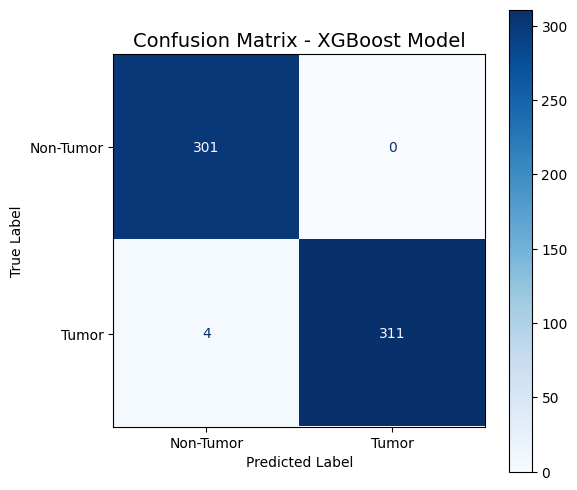

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display with labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Tumor", "Tumor"]
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.title("Confusion Matrix - XGBoost Model", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.grid(False)
plt.show()

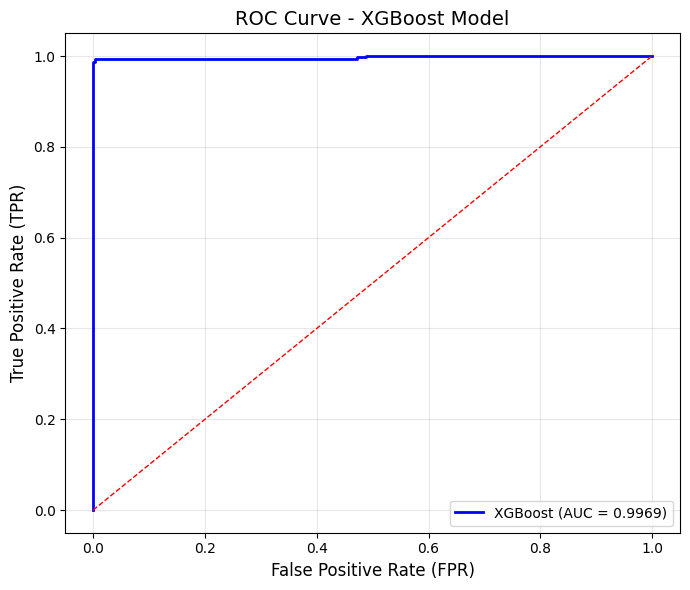

ROC-AUC Score: 0.9969308653694036


In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f"XGBoost (AUC = {roc_auc:.4f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1)

# Labels & title
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title("ROC Curve - XGBoost Model", fontsize=14)

# Legend
plt.legend(loc="lower right")

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print AUC
print("ROC-AUC Score:", roc_auc)

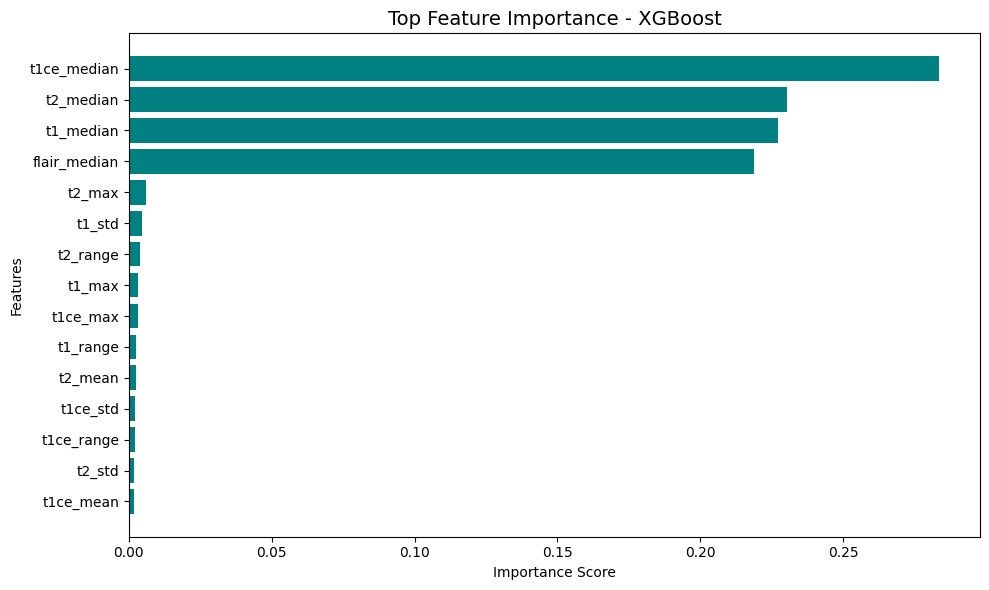

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature names from dataframe
feature_names = X.columns  # IMPORTANT

# Get importance values
importances = model.feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Select top 15 features (clean visualization)
top_n = 15
feat_df_top = feat_df.head(top_n)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df_top["Feature"], feat_df_top["Importance"], color="teal")
plt.gca().invert_yaxis()

plt.title("Top Feature Importance - XGBoost", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier
import pandas as pd

# ===============================
# MODELS (OPTIMIZED)
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        C=1.0
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

# ===============================
# TRAIN + EVALUATE
# ===============================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC-AUC": auc
    })

    print(f"{name}: Accuracy = {acc:.4f}, AUC = {auc:.4f}")

# ===============================
# RESULT TABLE
# ===============================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\nFinal Comparison:\n")
print(results_df)

Logistic Regression: Accuracy = 0.9789, AUC = 0.9977
SVM: Accuracy = 0.9708, AUC = 0.9879
KNN: Accuracy = 0.9903, AUC = 0.9935
Random Forest: Accuracy = 0.9919, AUC = 0.9993
Gradient Boosting: Accuracy = 0.9935, AUC = 0.9974
XGBoost: Accuracy = 0.9935, AUC = 0.9969

Final Comparison:

                 Model  Accuracy   ROC-AUC
4    Gradient Boosting  0.993506  0.997421
5              XGBoost  0.993506  0.996910
3        Random Forest  0.991883  0.999262
2                  KNN  0.990260  0.993524
0  Logistic Regression  0.978896  0.997659
1                  SVM  0.970779  0.987892


In [56]:
import pandas as pd

# Convert results (list of dicts) to DataFrame
results_df = pd.DataFrame(results)

# Sort by Accuracy (or use ROC-AUC if needed)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# Display nicely
print("\nFinal Model Comparison:\n")
print(results_df.to_string(index=False))


Final Model Comparison:

              Model  Accuracy  ROC-AUC
  Gradient Boosting  0.993506 0.997421
            XGBoost  0.993506 0.996910
      Random Forest  0.991883 0.999262
                KNN  0.990260 0.993524
Logistic Regression  0.978896 0.997659
                SVM  0.970779 0.987892


In [57]:
import os
import cv2
import nibabel as nib
import numpy as np
from nibabel.processing import resample_from_to

# ===============================
# OUTPUT FOLDERS
# ===============================
img_dir = "/content/dl_dataset"
os.makedirs(os.path.join(img_dir, "tumor"), exist_ok=True)
os.makedirs(os.path.join(img_dir, "non_tumor"), exist_ok=True)

saved_count = 0

# ===============================
# MAIN LOOP (INCREASE PATIENTS)
# ===============================
for patient in patients[:150]:  # 🔥 increased from 50 → 150
    p_path = os.path.join(base_path, patient)

    mri_path = os.path.join(p_path, "brain_t1ce.nii.gz")
    mask_path = os.path.join(p_path, "tumorseg_manual_correction.nii.gz")

    if not (os.path.exists(mri_path) and os.path.exists(mask_path)):
        continue

    try:
        # ------------------------------
        # LOAD MRI
        # ------------------------------
        mri_img = nib.load(mri_path)
        mri = mri_img.get_fdata()

        # ------------------------------
        # LOAD + RESAMPLE MASK
        # ------------------------------
        mask_img = nib.load(mask_path)
        mask_resampled = resample_from_to(mask_img, mri_img, order=0)
        mask = mask_resampled.get_fdata()

        num_slices = min(mri.shape[2], mask.shape[2])

        # ------------------------------
        # FIND TUMOR SLICES
        # ------------------------------
        tumor_areas = np.array([np.sum(mask[:, :, i]) for i in range(num_slices)])

        tumor_slices = np.where(tumor_areas > 0)[0]
        non_tumor_slices = np.where(tumor_areas == 0)[0]

        # ===============================
        # SAVE TUMOR IMAGES (MORE SAMPLES)
        # ===============================
        for i in tumor_slices[:10]:  # 🔥 increased from 5 → 10

            img = mri[:, :, i]

            if np.max(img) == 0:
                continue

            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
            img = cv2.resize(img, (224, 224))

            base_name = f"{patient}_{i}"

            # Save original
            cv2.imwrite(os.path.join(img_dir, "tumor", base_name + ".png"), img)

            # 🔥 Augmentation (flip)
            cv2.imwrite(os.path.join(img_dir, "tumor", base_name + "_flip.png"), cv2.flip(img, 1))

            saved_count += 2

        # ===============================
        # SAVE NON-TUMOR IMAGES (BALANCED)
        # ===============================
        step = max(1, len(non_tumor_slices)//10)

        for i in non_tumor_slices[::step][:10]:  # 🔥 increased

            img = mri[:, :, i]

            if np.max(img) == 0:
                continue

            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
            img = cv2.resize(img, (224, 224))

            base_name = f"{patient}_{i}"

            # Save original
            cv2.imwrite(os.path.join(img_dir, "non_tumor", base_name + ".png"), img)

            # 🔥 Augmentation (flip)
            cv2.imwrite(os.path.join(img_dir, "non_tumor", base_name + "_flip.png"), cv2.flip(img, 1))

            saved_count += 2

    except Exception as e:
        print(f"Skipping {patient}: {e}")

print("Total images saved:", saved_count)

Total images saved: 3260


In [58]:
print(len(os.listdir(img_dir + "/tumor")))
print(len(os.listdir(img_dir + "/non_tumor")))

1700
1560


In [59]:
# ===============================
# IMPORTS
# ===============================
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn, optim
from sklearn.metrics import accuracy_score

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ===============================
# TRANSFORMS (WITH AUGMENTATION)
# ===============================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),

    # 🔥 Augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# ===============================
# MODEL (TRANSFER LEARNING)
# ===============================
resnet = torchvision.models.resnet18(weights="IMAGENET1K_V1")

# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

resnet = resnet.to(device)

# ===============================
# LOSS & OPTIMIZER
# ===============================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    resnet.fc.parameters(),  # only last layer
    lr=0.0001
)

# ===============================
# TRAINING LOOP
# ===============================
epochs = 5

for epoch in range(epochs):
    resnet.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

# ===============================
# EVALUATION
# ===============================
resnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = resnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print("\nResNet Accuracy:", acc)

Using device: cuda
Total images: 3260
Classes: ['non_tumor', 'tumor']
Epoch 1/5, Loss: 51.1272
Epoch 2/5, Loss: 46.8096
Epoch 3/5, Loss: 45.5929
Epoch 4/5, Loss: 44.2222
Epoch 5/5, Loss: 43.1827

ResNet Accuracy: 0.7607361963190185


In [60]:
# ===============================
# IMPORTS
# ===============================
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn, optim
from sklearn.metrics import accuracy_score

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ===============================
# TRANSFORMS (WITH AUGMENTATION)
# ===============================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),

    # 🔥 Data Augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# ===============================
# MODEL (EFFICIENTNET-B0)
# ===============================
efficientnet = torchvision.models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze backbone
for param in efficientnet.parameters():
    param.requires_grad = False

# Replace classifier
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, 2
)

efficientnet = efficientnet.to(device)

# ===============================
# LOSS & OPTIMIZER
# ===============================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    efficientnet.classifier.parameters(),  # only classifier
    lr=0.0001
)

# ===============================
# TRAINING LOOP
# ===============================
epochs = 5

for epoch in range(epochs):
    efficientnet.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

# ===============================
# EVALUATION
# ===============================
efficientnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print("\nEfficientNet Accuracy:", acc)

Using device: cuda
Total images: 3260
Classes: ['non_tumor', 'tumor']
Epoch 1/5, Loss: 50.5704
Epoch 2/5, Loss: 45.9585
Epoch 3/5, Loss: 43.7632
Epoch 4/5, Loss: 43.0821
Epoch 5/5, Loss: 42.0272

EfficientNet Accuracy: 0.8067484662576687


In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, name="Model"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Metrics
    acc = accuracy_score(all_labels, all_preds)

    print(f"\n{name} Results:")
    print("Accuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    return acc

In [62]:
resnet_acc = evaluate_model(resnet, "ResNet")
effnet_acc = evaluate_model(efficientnet, "EfficientNet")

print("\nFinal DL Results:")
print("ResNet Accuracy:", resnet_acc)
print("EfficientNet Accuracy:", effnet_acc)


ResNet Results:
Accuracy: 0.754601226993865

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.68      0.72       306
           1       0.74      0.82      0.78       346

    accuracy                           0.75       652
   macro avg       0.76      0.75      0.75       652
weighted avg       0.76      0.75      0.75       652

Confusion Matrix:
[[209  97]
 [ 63 283]]

EfficientNet Results:
Accuracy: 0.8098159509202454

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       306
           1       0.78      0.89      0.83       346

    accuracy                           0.81       652
   macro avg       0.82      0.80      0.81       652
weighted avg       0.82      0.81      0.81       652

Confusion Matrix:
[[220  86]
 [ 38 308]]

Final DL Results:
ResNet Accuracy: 0.754601226993865
EfficientNet Accuracy: 0.8098159509202454


In [63]:
# ===============================
# IMPORTS
# ===============================
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ===============================
# TRANSFORMS (FIXED)
# ===============================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),   # 🔥 important
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # 🔥 fixed
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))

Using device: cuda
Total images: 3260
Classes: ['non_tumor', 'tumor']
Train size: 2608
Test size: 652


In [64]:
import torchvision
from torch import nn

# ===============================
# LOAD PRETRAINED MODEL (UPDATED)
# ===============================
resnet = torchvision.models.resnet18(weights="IMAGENET1K_V1")

# ===============================
# FREEZE BACKBONE
# ===============================
for param in resnet.parameters():
    param.requires_grad = False

# ===============================
# REPLACE FINAL LAYER
# ===============================
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 2)

# ===============================
# SEND TO DEVICE
# ===============================
resnet = resnet.to(device)

print("ResNet model ready")

ResNet model ready


In [65]:
import torchvision
from torch import nn

# ===============================
# LOAD PRETRAINED MODEL (UPDATED)
# ===============================
efficientnet = torchvision.models.efficientnet_b0(weights="IMAGENET1K_V1")

# ===============================
# FREEZE BACKBONE
# ===============================
for param in efficientnet.parameters():
    param.requires_grad = False

# ===============================
# REPLACE CLASSIFIER
# ===============================
num_features = efficientnet.classifier[1].in_features

efficientnet.classifier[1] = nn.Linear(num_features, 2)

# ===============================
# SEND TO DEVICE
# ===============================
efficientnet = efficientnet.to(device)

print("EfficientNet model ready")

EfficientNet model ready


In [31]:
from torch import optim
from torch import nn

# ===============================
# LOSS FUNCTION
# ===============================
criterion = nn.CrossEntropyLoss()

# ===============================
# RESNET OPTIMIZER
# ===============================
resnet_optimizer = optim.Adam(
    resnet.fc.parameters(),   # train only final layer
    lr=1e-4,                  # 🔥 reduced for stability
    weight_decay=1e-4         # 🔥 regularization
)

# ===============================
# EFFICIENTNET OPTIMIZER
# ===============================
eff_optimizer = optim.Adam(
    efficientnet.classifier.parameters(),  # train classifier only
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizers ready")

Optimizers ready


In [66]:
def train_model(model, optimizer, epochs=8, name="Model"):
    best_acc = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        print(f"{name} | Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc

    print(f"\nBest {name} Validation Accuracy: {best_acc:.4f}")

    return best_acc   # 🔥 THIS LINE FIXES YOUR ERROR

In [67]:
print("="*50)
print("🚀 Training ResNet Model")
print("="*50)

resnet_acc = train_model(
    resnet,
    resnet_optimizer,
    epochs=8,
    name="ResNet"
)

print("\n" + "="*50)
print("🚀 Training EfficientNet Model")
print("="*50)

effnet_acc = train_model(
    efficientnet,
    eff_optimizer,
    epochs=8,
    name="EfficientNet"
)

print("\n" + "="*50)
print("🏁 FINAL DL RESULTS")
print("="*50)

print(f"ResNet Best Accuracy: {resnet_acc:.4f}")
print(f"EfficientNet Best Accuracy: {effnet_acc:.4f}")

🚀 Training ResNet Model
ResNet | Epoch 1/8 | Loss: 55.4226 | Train Acc: 0.5893 | Val Acc: 0.6196
ResNet | Epoch 2/8 | Loss: 56.0200 | Train Acc: 0.5847 | Val Acc: 0.5752
ResNet | Epoch 3/8 | Loss: 55.1787 | Train Acc: 0.5932 | Val Acc: 0.5874
ResNet | Epoch 4/8 | Loss: 56.0756 | Train Acc: 0.5832 | Val Acc: 0.6043
ResNet | Epoch 5/8 | Loss: 56.0996 | Train Acc: 0.5878 | Val Acc: 0.6012
ResNet | Epoch 6/8 | Loss: 55.8680 | Train Acc: 0.5978 | Val Acc: 0.5905
ResNet | Epoch 7/8 | Loss: 55.9801 | Train Acc: 0.5890 | Val Acc: 0.6104
ResNet | Epoch 8/8 | Loss: 55.3764 | Train Acc: 0.5985 | Val Acc: 0.5982

Best ResNet Validation Accuracy: 0.6196

🚀 Training EfficientNet Model
EfficientNet | Epoch 1/8 | Loss: 59.7599 | Train Acc: 0.4271 | Val Acc: 0.4356
EfficientNet | Epoch 2/8 | Loss: 60.2594 | Train Acc: 0.3903 | Val Acc: 0.3589
EfficientNet | Epoch 3/8 | Loss: 59.8764 | Train Acc: 0.4072 | Val Acc: 0.3512
EfficientNet | Epoch 4/8 | Loss: 60.0381 | Train Acc: 0.3961 | Val Acc: 0.3620
Effi

In [68]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

y = df["label"]

# ===============================
# SINGLE MODALITY (T1 ONLY)
# ===============================
t1_cols = [col for col in df.columns if col.startswith("t1_")]
X_t1 = df[t1_cols]

Xtr, Xte, ytr, yte = train_test_split(X_t1, y, test_size=0.3, random_state=42)

model_t1 = XGBClassifier(eval_metric='logloss')
model_t1.fit(Xtr, ytr)

pred_t1 = model_t1.predict(Xte)
acc_t1 = accuracy_score(yte, pred_t1)

# ===============================
# MULTI-MODAL (ALL FEATURES)
# ===============================
X_full = df.drop(["label", "patient"], axis=1)

Xtr, Xte, ytr, yte = train_test_split(X_full, y, test_size=0.3, random_state=42)

model_multi = XGBClassifier(eval_metric='logloss')
model_multi.fit(Xtr, ytr)

pred_multi = model_multi.predict(Xte)
acc_multi = accuracy_score(yte, pred_multi)

# ===============================
# RESULT
# ===============================
print("T1 Only Accuracy:", acc_t1)
print("Multi-Modal Accuracy:", acc_multi)

T1 Only Accuracy: 0.9901315789473685
Multi-Modal Accuracy: 0.993421052631579
